<a href="https://colab.research.google.com/github/regmiresearch/ImageProcessingProjects/blob/main/Chapter06/Road_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
if not os.path.exists('GTSRB'):
    %pip install -U -q torch_snippets
    !wget -qq https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
    !wget -qq https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
    !unzip -qq GTSRB_Final_Training_Images.zip
    !unzip -qq GTSRB_Final_Test_Images.zip
    !wget https://raw.githubusercontent.com/georgesung/traffic_sign_classification_german/master/signnames.csv
    !rm GTSRB_Final_Training_Images.zip GTSRB_Final_Test_Images.zip


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.2/469.2 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.2 MB/s eta 0:00:00
--

[06/06/26 14:13:05] INFO     29406                                                                                                                  ]8;id=649838;file:///tmp/ipykernel_536/634365742.py:46\634365742.py]8;;\:]8;id=864690;file:///tmp/ipykernel_536/634365742.py:46#__init__:46\__init__:46]8;;\

                    INFO     9803                                                                                                                   ]8;id=576475;file:///tmp/ipykernel_536/634365742.py:46\634365742.py]8;;\:]8;id=803432;file:///tmp/ipykernel_536/634365742.py:46#__init__:46\__init__:46]8;;\

EPOCH: 1.000  val_acc: 0.518  trn_acc: 0.306  trn_loss: 2.353  val_loss: 1.482  (27.20s - 1060.98s remaining)
EPOCH: 2.000  val_acc: 0.709  trn_acc: 0.640  trn_loss: 1.101  val_loss: 0.868  (51.99s - 987.84s remaining)
EPOCH: 3.000  val_acc: 0.786  trn_acc: 0.756  trn_loss: 0.741  val_loss: 0.653  (80.87s - 997.37s remaining)
EPOCH: 4.000  val_acc: 0.821  trn_acc: 0.804  trn_loss: 0.598  val_loss: 0.560  (105.41s - 948.72s remaining)
EPOCH: 5.000  val_acc: 0.847  trn_acc: 0.827  trn_loss: 0.516  val_loss: 0.472  (131.80s - 922.57s remaining)
EPOCH: 6.000  val_acc: 0.862  trn_acc: 0.847  trn_loss: 0.469  val_loss: 0.424  (156.18s - 885.03s remaining)
EPOCH: 7.000  val_acc: 0.871  trn_acc: 0.859  trn_loss: 0.426  val_loss: 0.393  (180.78s - 852.23s remaining)
EPOCH: 8.000  val_acc: 0.875  trn_acc: 0.872  trn_loss: 0.395  val_loss: 0.378  (206.42s - 825.66s remaining)
EPOCH: 9.000  val_acc: 0.863  trn_acc: 0.878  trn_loss: 0.378  val_loss: 0.425  (230.93s - 795.44s remaining)
EPOCH: 10.00

100%|██████████| 141/141 [00:03<00:00, 41.37it/s]


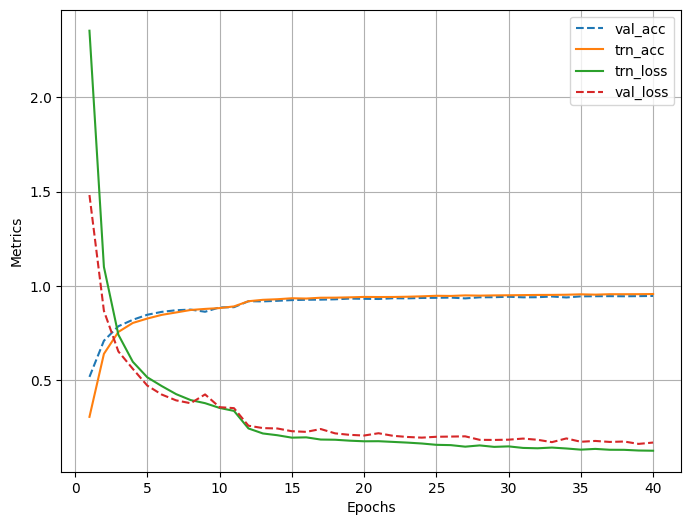

[06/06/26 14:29:58] INFO     Dumped object of size ≈2 MB @ "no-aug-no-bn.log" in 1.29e+00 seconds                                            ]8;id=431896;file:///tmp/ipykernel_536/634365742.py:155\634365742.py]8;;\:<cell line: 0>:155

» no-aug-no-bn.log

In [2]:
from torch_snippets import *
classIds = pd.read_csv('signnames.csv')
classIds.set_index('ClassId', inplace=True)
classIds = classIds.to_dict()['SignName']
classIds = {f'{k:05d}':v for k,v in classIds.items()}
id2int = {v:ix for ix,(k,v) in enumerate(classIds.items())}

from torchvision import transforms as T
classIds = pd.read_csv('signnames.csv')
classIds.set_index('ClassId', inplace=True)
classIds = classIds.to_dict()['SignName']
classIds = {f'{k:05d}':v for k,v in classIds.items()}
id2int = {v:ix for ix,(k,v) in enumerate(classIds.items())}

from torchvision import transforms as T

trn_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(32),
    T.CenterCrop(32),
    # T.ColorJitter(brightness=(0.8,1.2),
    # contrast=(0.8,1.2),
    # saturation=(0.8,1.2),
    # hue=0.25),
    # T.RandomAffine(5, translate=(0.01,0.1)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(32),
    T.CenterCrop(32),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

class GTSRB(Dataset):
    """Face Landmarks dataset."""

    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
        logger.info(len(self))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, ix):
        try:
            fpath = self.files[ix]
            clss = fname(parent(fpath))
            img = read(fpath, 1)
            return img, classIds[clss]
        except:
            Warn(f'Missing {fpath}. Loading a different image')
            return self[randint(len(self))]

    def choose(self):
        return self[randint(len(self))]

    def collate_fn(self, batch):
        imgs, classes = list(zip(*batch))
        if self.transform:
            imgs = [self.transform(img)[None] for img in imgs]
        classes = [torch.tensor([id2int[clss]]) for clss in classes]
        imgs, classes = [torch.cat(i).to(device) for i in [imgs, classes]]
        return imgs, classes

device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_files = Glob('GTSRB/Final_Training/Images/*/*.ppm')
np.random.seed(10)
np.random.shuffle(all_files)

from sklearn.model_selection import train_test_split
trn_files, val_files = train_test_split(all_files, random_state=1)

trn_ds = GTSRB(trn_files, transform=trn_tfms)
val_ds = GTSRB(val_files, transform=val_tfms)
trn_dl = DataLoader(trn_ds, 32, shuffle=True, collate_fn=trn_ds.collate_fn)
val_dl = DataLoader(val_ds, 32, shuffle=False, collate_fn=val_ds.collate_fn)

import torchvision.models as models

def convBlock(ni, no):
    return nn.Sequential(
        nn.Dropout(0.2),
        nn.Conv2d(ni, no, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        #nn.BatchNorm2d(no),
        nn.MaxPool2d(2),
    )

class SignClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            convBlock(3, 64),
            convBlock(64, 64),
            convBlock(64, 128),
            convBlock(128, 64),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.Dropout(0.2),
            nn.ReLU(inplace=True),
            nn.Linear(256, len(id2int))
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def compute_metrics(self, preds, targets):
        ce_loss = self.loss_fn(preds, targets)
        acc = (torch.max(preds, 1)[1] == targets).float().mean()
        return ce_loss, acc
def train_batch(model, data, optimizer, criterion):
    ims, labels = data
    _preds = model(ims)
    optimizer.zero_grad()
    loss, acc = criterion(_preds, labels)
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, data, criterion):
    ims, labels = data
    _preds = model(ims)
    loss, acc = criterion(_preds, labels)
    return loss.item(), acc.item()
model = SignClassifier().to(device)
criterion = model.compute_metrics
optimizer = optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 40

log = Report(n_epochs)
for ex in range(n_epochs):
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss, acc = train_batch(model, data, optimizer, criterion)
        log.record(ex+(bx+1)/N, trn_loss=loss, trn_acc=acc, end='\r')

    N = len(val_dl)
    for bx, data in enumerate(val_dl):
        loss, acc = validate_batch(model, data, criterion)
        log.record(ex+(bx+1)/N, val_loss=loss, val_acc=acc, end='\r')

    log.report_avgs(ex+1)
    if ex == 10: optimizer = optim.Adam(model.parameters(), lr=1e-4)

log.plot_epochs()
dumpdill(log, 'no-aug-no-bn.log')

[06/06/26 14:29:59] INFO     29406                                                                                                                 ]8;id=610765;file:///tmp/ipykernel_536/1114352175.py:46\1114352175.py]8;;\:]8;id=794299;file:///tmp/ipykernel_536/1114352175.py:46#__init__:46\__init__:46]8;;\

                    INFO     9803                                                                                                                  ]8;id=205160;file:///tmp/ipykernel_536/1114352175.py:46\1114352175.py]8;;\:]8;id=956895;file:///tmp/ipykernel_536/1114352175.py:46#__init__:46\__init__:46]8;;\

EPOCH: 1.000  val_acc: 0.815  trn_acc: 0.567  trn_loss: 1.433  val_loss: 0.567  (34.77s - 1356.07s remaining)
EPOCH: 2.000  val_acc: 0.889  trn_acc: 0.854  trn_loss: 0.444  val_loss: 0.344  (60.11s - 1142.12s remaining)
EPOCH: 3.000  val_acc: 0.907  trn_acc: 0.901  trn_loss: 0.299  val_loss: 0.288  (85.45s - 1053.87s remaining)
EPOCH: 4.000  val_acc: 0.928  trn_acc: 0.921  trn_loss: 0.239  val_loss: 0.226  (113.75s - 1023.74s remaining)
EPOCH: 5.000  val_acc: 0.938  trn_acc: 0.938  trn_loss: 0.194  val_loss: 0.183  (139.32s - 975.25s remaining)
EPOCH: 6.000  val_acc: 0.931  trn_acc: 0.943  trn_loss: 0.172  val_loss: 0.214  (165.31s - 936.76s remaining)
EPOCH: 7.000  val_acc: 0.946  trn_acc: 0.952  trn_loss: 0.145  val_loss: 0.174  (195.07s - 919.62s remaining)
EPOCH: 8.000  val_acc: 0.954  trn_acc: 0.954  trn_loss: 0.136  val_loss: 0.144  (219.60s - 878.42s remaining)
EPOCH: 9.000  val_acc: 0.953  trn_acc: 0.958  trn_loss: 0.121  val_loss: 0.146  (244.50s - 842.18s remaining)
EPOCH: 10

100%|██████████| 141/141 [00:02<00:00, 58.40it/s]


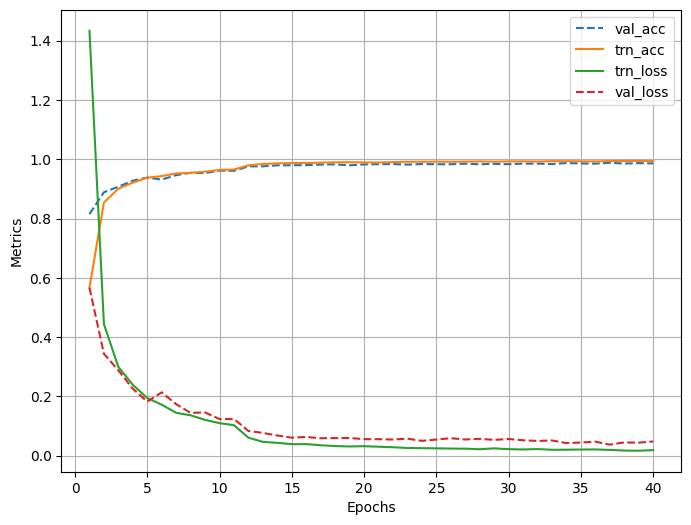

[06/06/26 14:46:55] INFO     Dumped object of size ≈2 MB @ "no-aug-yes-bn.log" in 1.61e+00 seconds                                          ]8;id=113098;file:///tmp/ipykernel_536/1114352175.py:155\1114352175.py]8;;\:<cell line: 0>:155

» no-aug-yes-bn.log

In [3]:
from torch_snippets import *
classIds = pd.read_csv('signnames.csv')
classIds.set_index('ClassId', inplace=True)
classIds = classIds.to_dict()['SignName']
classIds = {f'{k:05d}':v for k,v in classIds.items()}
id2int = {v:ix for ix,(k,v) in enumerate(classIds.items())}

from torchvision import transforms as T
classIds = pd.read_csv('signnames.csv')
classIds.set_index('ClassId', inplace=True)
classIds = classIds.to_dict()['SignName']
classIds = {f'{k:05d}':v for k,v in classIds.items()}
id2int = {v:ix for ix,(k,v) in enumerate(classIds.items())}

from torchvision import transforms as T

trn_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(32),
    T.CenterCrop(32),
    # T.ColorJitter(brightness=(0.8,1.2),
    # contrast=(0.8,1.2),
    # saturation=(0.8,1.2),
    # hue=0.25),
    # T.RandomAffine(5, translate=(0.01,0.1)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(32),
    T.CenterCrop(32),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

class GTSRB(Dataset):
    """Face Landmarks dataset."""

    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
        logger.info(len(self))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, ix):
        try:
            fpath = self.files[ix]
            clss = fname(parent(fpath))
            img = read(fpath, 1)
            return img, classIds[clss]
        except:
            Warn(f'Missing {fpath}. Loading a different image')
            return self[randint(len(self))]

    def choose(self):
        return self[randint(len(self))]

    def collate_fn(self, batch):
        imgs, classes = list(zip(*batch))
        if self.transform:
            imgs = [self.transform(img)[None] for img in imgs]
        classes = [torch.tensor([id2int[clss]]) for clss in classes]
        imgs, classes = [torch.cat(i).to(device) for i in [imgs, classes]]
        return imgs, classes

device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_files = Glob('GTSRB/Final_Training/Images/*/*.ppm')
np.random.seed(10)
np.random.shuffle(all_files)

from sklearn.model_selection import train_test_split
trn_files, val_files = train_test_split(all_files, random_state=1)

trn_ds = GTSRB(trn_files, transform=trn_tfms)
val_ds = GTSRB(val_files, transform=val_tfms)
trn_dl = DataLoader(trn_ds, 32, shuffle=True, collate_fn=trn_ds.collate_fn)
val_dl = DataLoader(val_ds, 32, shuffle=False, collate_fn=val_ds.collate_fn)

import torchvision.models as models

def convBlock(ni, no):
    return nn.Sequential(
        nn.Dropout(0.2),
        nn.Conv2d(ni, no, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(no),
        nn.MaxPool2d(2),
    )

class SignClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            convBlock(3, 64),
            convBlock(64, 64),
            convBlock(64, 128),
            convBlock(128, 64),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.Dropout(0.2),
            nn.ReLU(inplace=True),
            nn.Linear(256, len(id2int))
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def compute_metrics(self, preds, targets):
        ce_loss = self.loss_fn(preds, targets)
        acc = (torch.max(preds, 1)[1] == targets).float().mean()
        return ce_loss, acc
def train_batch(model, data, optimizer, criterion):
    ims, labels = data
    _preds = model(ims)
    optimizer.zero_grad()
    loss, acc = criterion(_preds, labels)
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, data, criterion):
    ims, labels = data
    _preds = model(ims)
    loss, acc = criterion(_preds, labels)
    return loss.item(), acc.item()
model = SignClassifier().to(device)
criterion = model.compute_metrics
optimizer = optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 40

log = Report(n_epochs)
for ex in range(n_epochs):
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss, acc = train_batch(model, data, optimizer, criterion)
        log.record(ex+(bx+1)/N, trn_loss=loss, trn_acc=acc, end='\r')

    N = len(val_dl)
    for bx, data in enumerate(val_dl):
        loss, acc = validate_batch(model, data, criterion)
        log.record(ex+(bx+1)/N, val_loss=loss, val_acc=acc, end='\r')

    log.report_avgs(ex+1)
    if ex == 10: optimizer = optim.Adam(model.parameters(), lr=1e-4)

log.plot_epochs()
dumpdill(log, 'no-aug-yes-bn.log')

[06/06/26 15:15:53] INFO     29406                                                                                                                 ]8;id=214400;file:///tmp/ipykernel_536/1406697498.py:46\1406697498.py]8;;\:]8;id=695462;file:///tmp/ipykernel_536/1406697498.py:46#__init__:46\__init__:46]8;;\

                    INFO     9803                                                                                                                  ]8;id=848531;file:///tmp/ipykernel_536/1406697498.py:46\1406697498.py]8;;\:]8;id=195491;file:///tmp/ipykernel_536/1406697498.py:46#__init__:46\__init__:46]8;;\

EPOCH: 1.000  val_acc: 0.748  trn_acc: 0.455  trn_loss: 1.852  val_loss: 0.763  (52.01s - 2028.37s remaining)
EPOCH: 2.000  val_acc: 0.834  trn_acc: 0.769  trn_loss: 0.714  val_loss: 0.491  (96.30s - 1829.67s remaining)
EPOCH: 3.000  val_acc: 0.878  trn_acc: 0.835  trn_loss: 0.503  val_loss: 0.371  (141.75s - 1748.23s remaining)
EPOCH: 4.000  val_acc: 0.894  trn_acc: 0.869  trn_loss: 0.402  val_loss: 0.323  (186.06s - 1674.52s remaining)
EPOCH: 5.000  val_acc: 0.917  trn_acc: 0.885  trn_loss: 0.347  val_loss: 0.254  (230.64s - 1614.47s remaining)
EPOCH: 6.000  val_acc: 0.915  trn_acc: 0.899  trn_loss: 0.307  val_loss: 0.250  (274.06s - 1553.02s remaining)
EPOCH: 7.000  val_acc: 0.924  trn_acc: 0.910  trn_loss: 0.270  val_loss: 0.224  (318.44s - 1501.21s remaining)
EPOCH: 8.000  val_acc: 0.939  trn_acc: 0.917  trn_loss: 0.252  val_loss: 0.185  (361.79s - 1447.15s remaining)
EPOCH: 9.000  val_acc: 0.937  trn_acc: 0.925  trn_loss: 0.231  val_loss: 0.187  (405.91s - 1398.14s remaining)
EPO

100%|██████████| 141/141 [00:03<00:00, 42.56it/s]


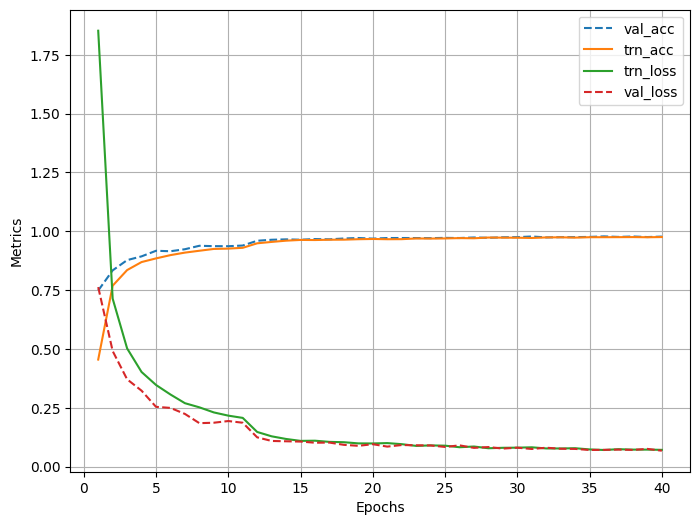

[06/06/26 15:45:21] INFO     Dumped object of size ≈2 MB @ "40-yes-aug-yes-bn.log" in 1.22e+00 seconds                                      ]8;id=830844;file:///tmp/ipykernel_536/1406697498.py:155\1406697498.py]8;;\:<cell line: 0>:155

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
from torch_snippets import *
classIds = pd.read_csv('signnames.csv')
classIds.set_index('ClassId', inplace=True)
classIds = classIds.to_dict()['SignName']
classIds = {f'{k:05d}':v for k,v in classIds.items()}
id2int = {v:ix for ix,(k,v) in enumerate(classIds.items())}

from torchvision import transforms as T
classIds = pd.read_csv('signnames.csv')
classIds.set_index('ClassId', inplace=True)
classIds = classIds.to_dict()['SignName']
classIds = {f'{k:05d}':v for k,v in classIds.items()}
id2int = {v:ix for ix,(k,v) in enumerate(classIds.items())}

from torchvision import transforms as T

trn_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(32),
    T.CenterCrop(32),
    T.ColorJitter(brightness=(0.8,1.2),
    contrast=(0.8,1.2),
    saturation=(0.8,1.2),
    hue=0.25),
    T.RandomAffine(5, translate=(0.01,0.1)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize(32),
    T.CenterCrop(32),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

class GTSRB(Dataset):
    """Face Landmarks dataset."""

    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform
        logger.info(len(self))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, ix):
        try:
            fpath = self.files[ix]
            clss = fname(parent(fpath))
            img = read(fpath, 1)
            return img, classIds[clss]
        except:
            Warn(f'Missing {fpath}. Loading a different image')
            return self[randint(len(self))]

    def choose(self):
        return self[randint(len(self))]

    def collate_fn(self, batch):
        imgs, classes = list(zip(*batch))
        if self.transform:
            imgs = [self.transform(img)[None] for img in imgs]
        classes = [torch.tensor([id2int[clss]]) for clss in classes]
        imgs, classes = [torch.cat(i).to(device) for i in [imgs, classes]]
        return imgs, classes

device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_files = Glob('GTSRB/Final_Training/Images/*/*.ppm')
np.random.seed(10)
np.random.shuffle(all_files)

from sklearn.model_selection import train_test_split
trn_files, val_files = train_test_split(all_files, random_state=1)

trn_ds = GTSRB(trn_files, transform=trn_tfms)
val_ds = GTSRB(val_files, transform=val_tfms)
trn_dl = DataLoader(trn_ds, 32, shuffle=True, collate_fn=trn_ds.collate_fn)
val_dl = DataLoader(val_ds, 32, shuffle=False, collate_fn=val_ds.collate_fn)

import torchvision.models as models

def convBlock(ni, no):
    return nn.Sequential(
        nn.Dropout(0.2),
        nn.Conv2d(ni, no, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(no),
        nn.MaxPool2d(2),
    )

class SignClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            convBlock(3, 64),
            convBlock(64, 64),
            convBlock(64, 128),
            convBlock(128, 64),
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.Dropout(0.2),
            nn.ReLU(inplace=True),
            nn.Linear(256, len(id2int))
        )
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def compute_metrics(self, preds, targets):
        ce_loss = self.loss_fn(preds, targets)
        acc = (torch.max(preds, 1)[1] == targets).float().mean()
        return ce_loss, acc
def train_batch(model, data, optimizer, criterion):
    ims, labels = data
    _preds = model(ims)
    optimizer.zero_grad()
    loss, acc = criterion(_preds, labels)
    loss.backward()
    optimizer.step()
    return loss.item(), acc.item()

@torch.no_grad()
def validate_batch(model, data, criterion):
    ims, labels = data
    _preds = model(ims)
    loss, acc = criterion(_preds, labels)
    return loss.item(), acc.item()
model = SignClassifier().to(device)
criterion = model.compute_metrics
optimizer = optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 40

log = Report(n_epochs)
for ex in range(n_epochs):
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss, acc = train_batch(model, data, optimizer, criterion)
        log.record(ex+(bx+1)/N, trn_loss=loss, trn_acc=acc, end='\r')

    N = len(val_dl)
    for bx, data in enumerate(val_dl):
        loss, acc = validate_batch(model, data, criterion)
        log.record(ex+(bx+1)/N, val_loss=loss, val_acc=acc, end='\r')

    log.report_avgs(ex+1)
    if ex == 10: optimizer = optim.Adam(model.parameters(), lr=1e-4)

log.plot_epochs()
dumpdill(log, '40-yes-aug-yes-bn.log')
from google.colab import files
files.download('40-yes-aug-yes-bn.log')


EPOCH: 20.000  trn_acc: 0.942  val_acc: 0.932  val_loss: 0.207  trn_loss: 0.176  (5536.04s - 5536.04s remaining)


100%|██████████| 141/141 [00:00<00:00, 142.01it/s]


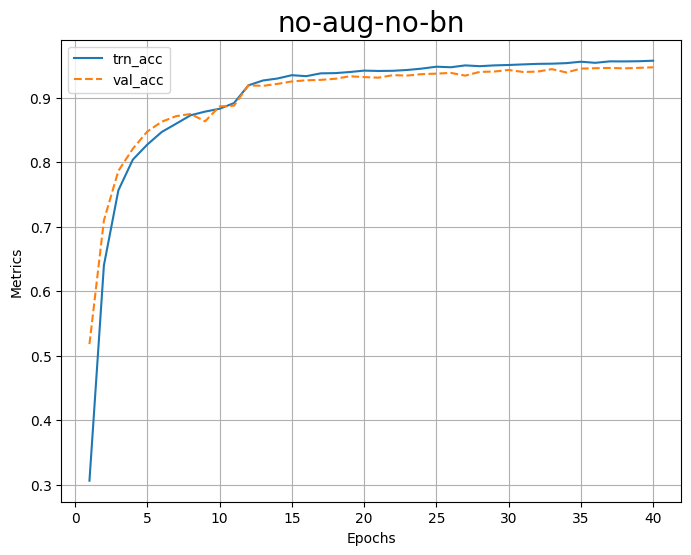


══════════════════════════════════════════════════════════════════

EPOCH: 20.000  trn_acc: 0.967  val_acc: 0.969  val_loss: 0.096  trn_loss: 0.099  (1769.48s - 1769.48s remaining)


100%|██████████| 141/141 [00:01<00:00, 140.84it/s]


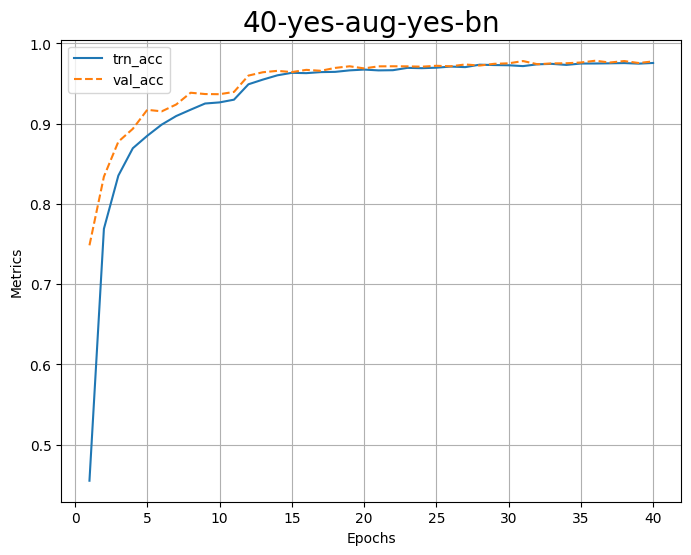


══════════════════════════════════════════════════════════════════

EPOCH: 20.000  trn_acc: 0.989  val_acc: 0.982  val_loss: 0.056  trn_loss: 0.032  (4524.94s - 4524.94s remaining)


100%|██████████| 141/141 [00:01<00:00, 136.37it/s]


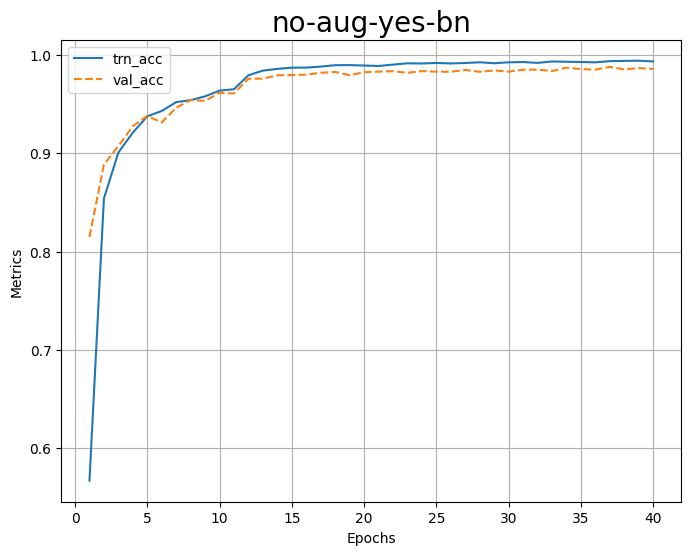


══════════════════════════════════════════════════════════════════


In [6]:
for f in Glob('*.log'):
    log = loaddill(f)
    print()
    log.report_avgs(20)
    log.plot_epochs(['trn_acc', 'val_acc'], title=str(f).replace(',','\n').replace('.log',''))
    print()
    line()